In [4]:
!pip install pandas numpy seaborn matplotlib scikit-learn catboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [94]:
df = pd.read_csv("customer_churn_dataset.csv")

In [95]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [96]:
df.isnull().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

In [97]:
df["churn"] = df["churn"].map({"Yes":1,"No":0})

In [98]:
print(df.head())
print(df.info())
print(df.describe())


   customer_id  tenure  monthly_charges  total_charges        contract  \
0            1      52            54.20        2818.40  Month-to-month   
1            2      15            35.28         529.20  Month-to-month   
2            3      72            78.24        5633.28  Month-to-month   
3            4      61            80.24        4894.64        One year   
4            5      21            39.38         826.98  Month-to-month   

  payment_method internet_service tech_support online_security  support_calls  \
0         Credit              DSL           No             Yes              1   
1          Debit              DSL           No              No              2   
2          Debit              DSL           No              No              0   
3           Cash            Fiber          Yes             Yes              0   
4            UPI            Fiber           No              No              4   

   churn  
0      0  
1      0  
2      0  
3      0  
4      1  
<c

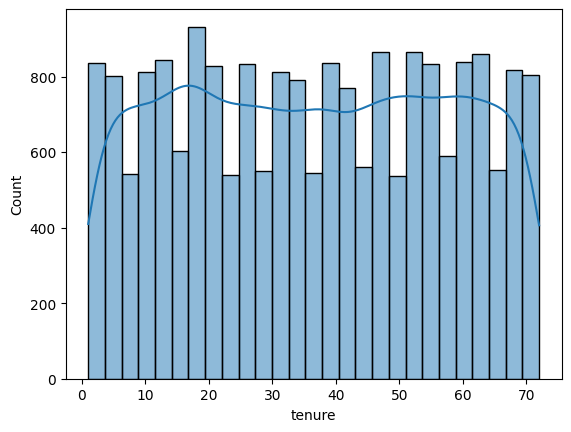

In [99]:
plt.figure()
sns.histplot(df["tenure"], kde=True)
plt.show()

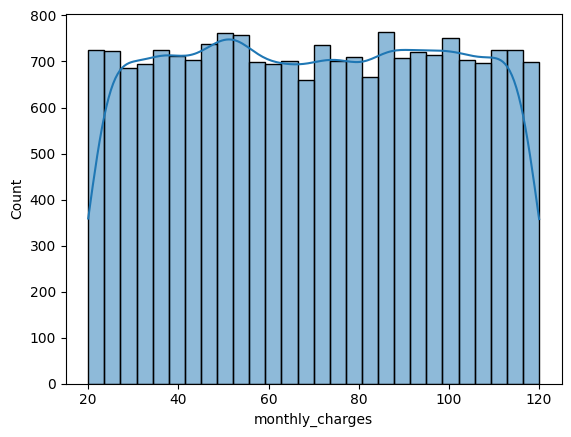

In [100]:
plt.figure()
sns.histplot(df["monthly_charges"], kde=True)
plt.show()

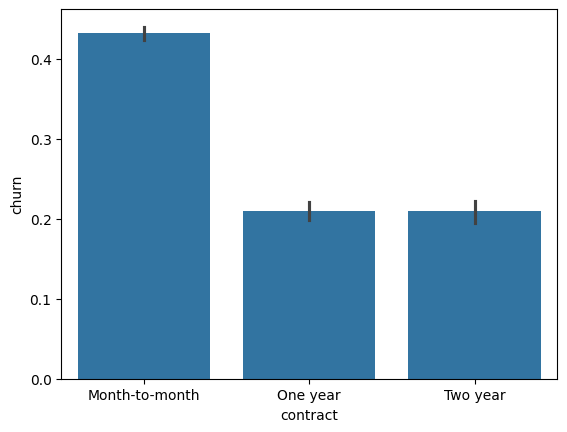

In [101]:
plt.figure()
sns.barplot(x="contract", y="churn", data=df)
plt.show()


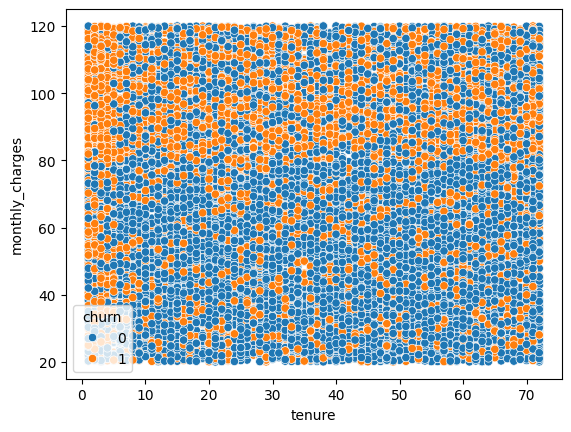

In [102]:
plt.figure()
sns.scatterplot(x="tenure", y="monthly_charges", hue="churn", data=df)
plt.show()

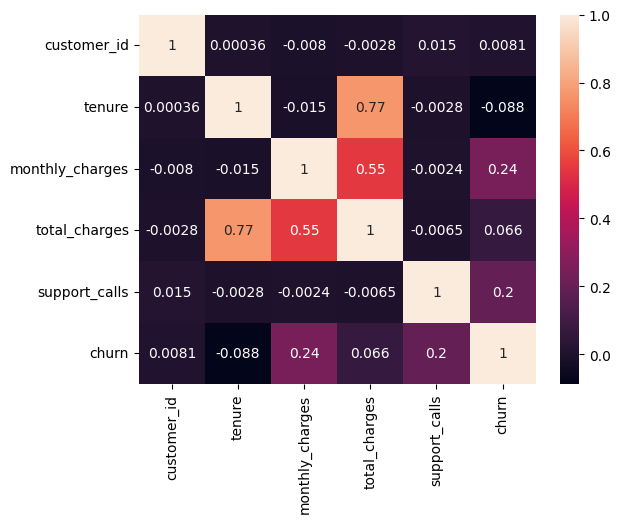

In [103]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [104]:
df = df.drop("customer_id",axis=1)

In [105]:
X = df.drop("churn", axis=1)
y = df["churn"]


In [106]:

cat_features = ["contract","payment_method","internet_service","tech_support","online_security"]


In [107]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [108]:
model = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, loss_function="Logloss", verbose=0)


In [109]:
df = df.fillna("Unknown")

In [110]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

In [111]:
df.isnull().sum()

tenure              0
monthly_charges     0
total_charges       0
contract            0
payment_method      0
internet_service    0
tech_support        0
online_security     0
support_calls       0
churn               0
dtype: int64

In [112]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [113]:
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

In [114]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [115]:
X = df.drop('churn', axis=1)
y = df['churn']

In [116]:
cat_columns = [
    'contract', 
    'payment_method', 
    'internet_service', 
    'tech_support', 
    'online_security'
]

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    random_seed=42,
    logging_level='Silent'
)

In [119]:
from catboost import CatBoostClassifier

In [120]:
df["churn"].isnull().sum()

np.int64(20000)

In [121]:
df["churn"].unique()

array([nan])

In [122]:
df["churn"] = df["churn"].replace(" ", np.nan)
df["churn"] = df["churn"].map({"Yes":1, "No":0})

In [123]:
df = df.dropna(subset=["churn"])

In [124]:
df["churn"].isnull().sum()

np.int64(0)

In [128]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [131]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

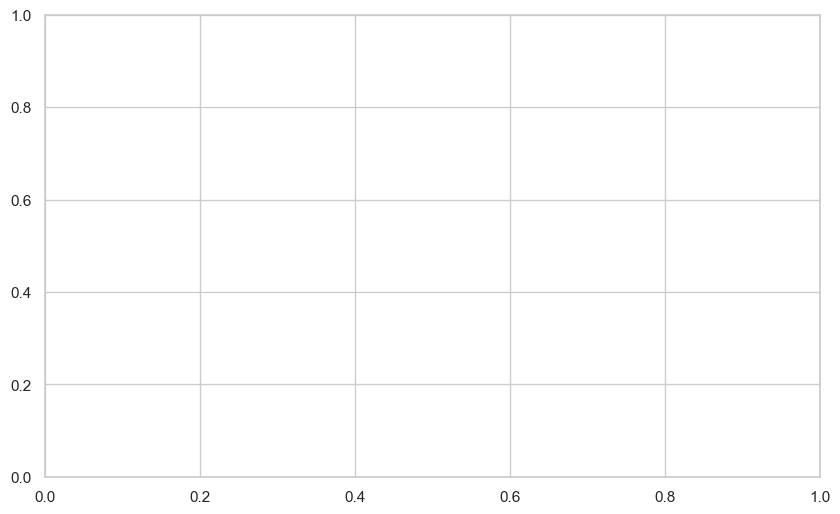

In [132]:
plt.figure()
sns.violinplot(x="contract", y="monthly_charges", hue="churn", data=df, split=True)
plt.show()


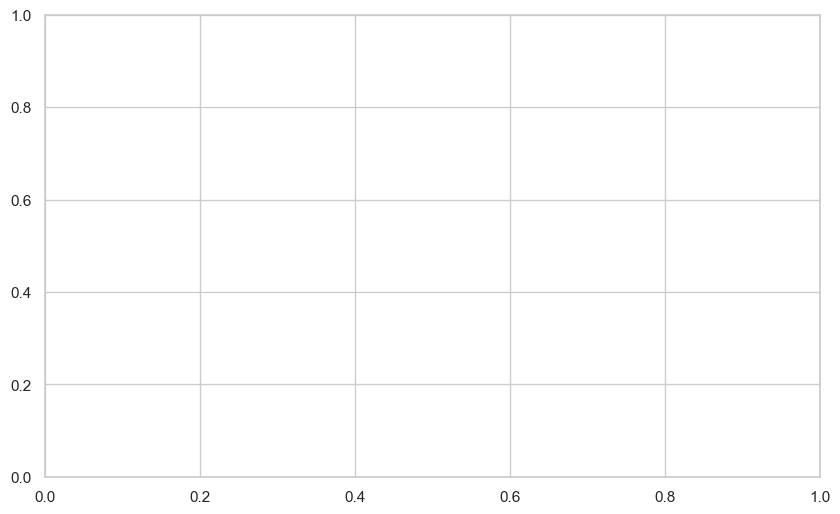

In [133]:

plt.figure()
sns.countplot(x="contract", hue="churn", data=df)
plt.show()
